# Session 3 — Visualisation & Data Preprocessing

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tech4alltraining/aiml/blob/main/mlai-genai-internship/student/notebooks/session-03-visualisation-preprocessing.ipynb)

**ML/AI & GenAI Internship** · Matplotlib & Seaborn · Missing Values · Duplicates · Outliers · Scaling · Encoding · Train-Test Split

---

## How to use this notebook

| # | Topic | # | Topic |
|---|---|---|---|
| 1 | Visualisation | 5 | Transformation & scaling |
| 2 | Missing values | 6 | Encoding |
| 3 | Duplicates | 7 | Train-test split |
| 4 | Outlier detection & removal | | |

Exercises, MCQs and tasks: [Session 3 guide](../sessions/session-03-visualisation-preprocessing.md).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
BASE = "https://raw.githubusercontent.com/tech4alltraining/aiml/refs/heads/main/datasets/"

df = pd.read_csv(BASE + "regression/cardekho_dataset.csv")
print("cardekho:", df.shape)

cardekho: (15411, 14)


---
# 1. Visualisation

🧠 **Charts are camera lenses.** You pick one for what you are photographing. **If you cannot say what question your chart answers, delete it.**

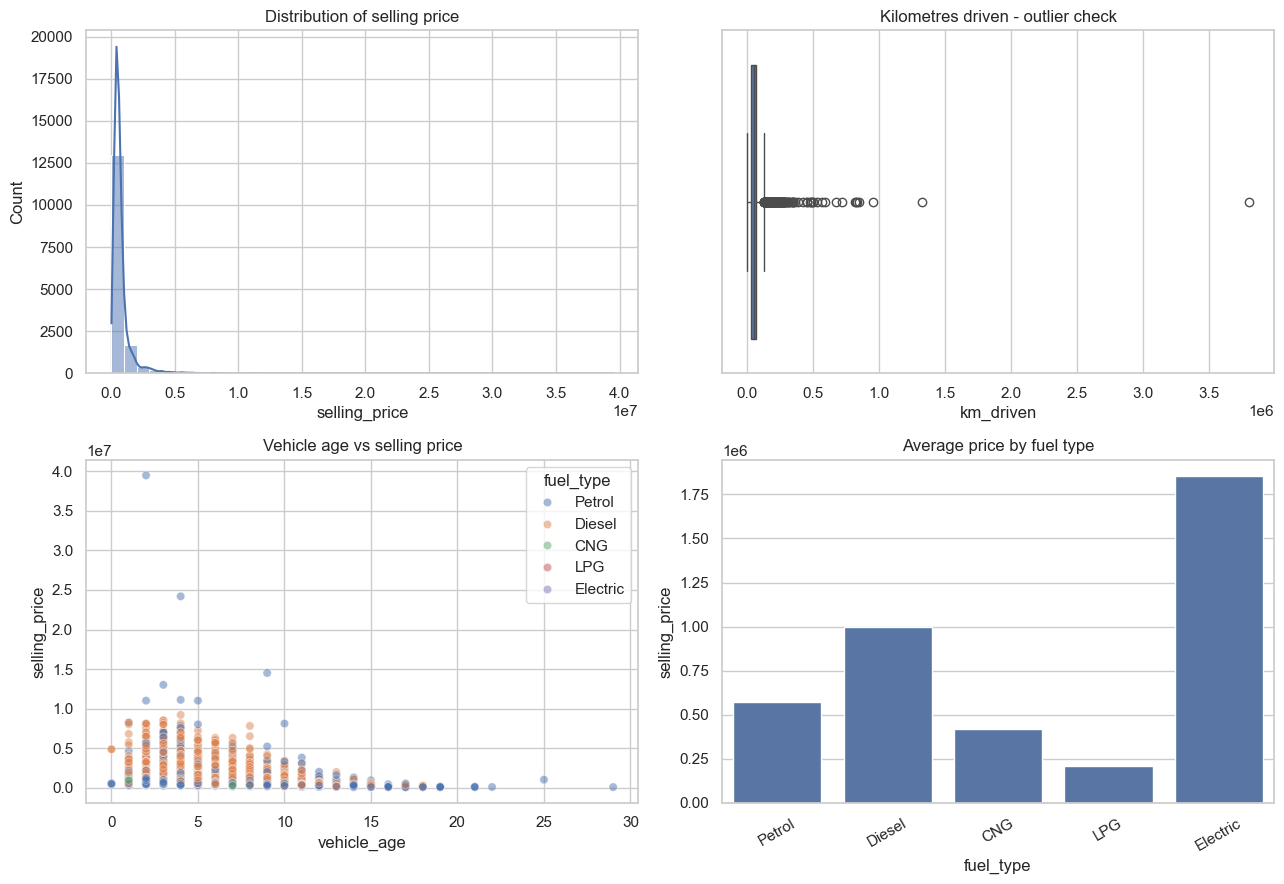

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# 1. HISTOGRAM - where does the data sit?
sns.histplot(df["selling_price"], bins=40, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Distribution of selling price")

# 2. BOX PLOT - is anything absurdly far from the rest?
sns.boxplot(x=df["km_driven"], ax=axes[0, 1])
axes[0, 1].set_title("Kilometres driven - outlier check")

# 3. SCATTER - do two things move together?
sns.scatterplot(x="vehicle_age", y="selling_price", hue="fuel_type",
                data=df, alpha=0.5, ax=axes[1, 0])
axes[1, 0].set_title("Vehicle age vs selling price")

# 4. BAR - which category is highest on average?
sns.barplot(x="fuel_type", y="selling_price", data=df, errorbar=None, ax=axes[1, 1])
axes[1, 1].set_title("Average price by fuel type")
axes[1, 1].tick_params(axis="x", rotation=30)

plt.tight_layout(); plt.show()

### 📊 How to read these

| Chart | What you look at | What it means |
|---|---|---|
| Histogram | A long flat tail to the right | **Right-skewed** — the mean sits above the median |
| Box plot | Dots past the whiskers | **Outliers** — candidates for investigation |
| Scatter | The overall direction | Downward = as age rises, price falls |
| Bar plot | Bar height | The **average** of another column per category |

> ⚠️ **The trap:** a category can be rare yet have a high average. **Always check the count plot before believing the bar plot.**

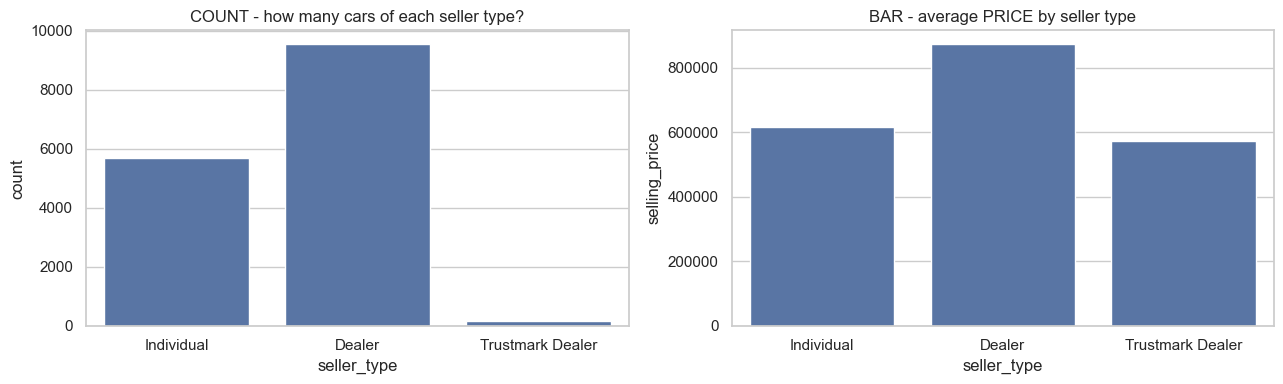

seller_type
Dealer              9539
Individual          5699
Trustmark Dealer     173
Name: count, dtype: int64

Is the highest-average category built on enough rows?


In [3]:
# COUNT plot vs BAR plot - the pair everyone confuses
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.countplot(x="seller_type", data=df, ax=axes[0])
axes[0].set_title("COUNT - how many cars of each seller type?")

sns.barplot(x="seller_type", y="selling_price", data=df, errorbar=None, ax=axes[1])
axes[1].set_title("BAR - average PRICE by seller type")

plt.tight_layout(); plt.show()

print(df["seller_type"].value_counts())
print("\nIs the highest-average category built on enough rows?")

---
# 2. Handling missing values

🧠 **Gaps in a form.** Throw the form away, guess a sensible value, or mark it as 'not given'. Each choice changes what you can conclude.

In [4]:
small = pd.read_csv(BASE + "prepreprocessing/pre_data.csv")
print(small)
print("\nmissing per column:")
print(small.isnull().sum())

    Country   Age     Salary Purchased
0    France  44.0    72000.0        No
1     Spain  27.0    48000.0       Yes
2       NaN  30.0    54000.0        No
3     Spain  38.0    61000.0        No
4   Germany  40.0        NaN       Yes
5    France  35.0    58000.0       Yes
6     Spain   NaN    52000.0        No
7    France  48.0    79000.0       Yes
8   Germany  50.0    83000.0        No
9    France  37.0    67000.0       Yes
10  Germany  50.0    83000.0        No
11    Spain  50.0  1500000.0        No

missing per column:
Country      1
Age          1
Salary       1
Purchased    0
dtype: int64


In [5]:
# MEDIAN, not mean - and here is the concrete reason.
print("mean  :", round(small["Salary"].mean(), 0), "  <- dragged by ONE row")
print("median:", round(small["Salary"].median(), 0), "  <- unaffected")
print("max   :", small["Salary"].max())

filled = small.copy()
filled["Salary"] = filled["Salary"].fillna(filled["Salary"].median())
filled["Age"] = filled["Age"].fillna(filled["Age"].median())
filled["Country"] = filled["Country"].fillna(filled["Country"].mode()[0])
print("\nremaining gaps:", filled.isnull().sum().sum())

mean  : 196091.0   <- dragged by ONE row
median: 67000.0   <- unaffected
max   : 1500000.0

remaining gaps: 0


In [6]:
# Sometimes a blank is INFORMATION. Keep the signal before you fill.
t = pd.read_csv(BASE + "classification/archive/titanic.csv")

print("age missing:", t["age"].isnull().sum(),
      f"({t['age'].isnull().mean()*100:.1f}%)")

t["age_missing"] = t["age"].isnull().astype(int)     # keep the signal
t["age"] = t["age"].fillna(t["age"].median())        # then fill

print("survival rate, age known   :", round(t[t.age_missing == 0]["survived"].mean(), 3))
print("survival rate, age missing :", round(t[t.age_missing == 1]["survived"].mean(), 3))
print("\nIf those differ, 'age was missing' is itself a useful feature.")

age missing: 177 (19.9%)
survival rate, age known   : 0.406
survival rate, age missing : 0.294

If those differ, 'age was missing' is itself a useful feature.


---
# 3. Removing duplicates

🧠 **The same form submitted twice.** Or two different people who genuinely gave the same answers. **You cannot tell which from the data alone.**

In [7]:
print("duplicate rows:", small.duplicated().sum())

# keep=False shows ALL copies, so you can compare them side by side
print("\nthe duplicates:")
print(small[small.duplicated(keep=False)])

before = len(small)
deduped = small.drop_duplicates().reset_index(drop=True)
print(f"\nremoved {before - len(deduped)} row(s): {before} -> {len(deduped)}")

duplicate rows: 1

the duplicates:
    Country   Age   Salary Purchased
8   Germany  50.0  83000.0        No
10  Germany  50.0  83000.0        No

removed 1 row(s): 12 -> 11


In [8]:
# Duplicates on ONE column are usually expected...
print("duplicate Country values:", deduped.duplicated(subset=["Country"]).sum())
print("  -> many people share a country. Expected.")

# ...but a repeated ID is almost always a real problem.
print("\nA repeated ID means double entry or a bad join - investigate it.")

duplicate Country values: 7
  -> many people share a country. Expected.

A repeated ID means double entry or a bad join - investigate it.


---
# 4. Outlier detection & removal

🧠 **The one very tall person in the class photo.** They are real, and not a mistake. But use the class average to order uniforms and everyone gets the wrong size.

**Detection finds candidates. You decide which is which.**

In [9]:
col = "km_driven"

q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr

print(f"Q1     {q1:>12,.0f}")
print(f"Q3     {q3:>12,.0f}")
print(f"IQR    {iqr:>12,.0f}")
print(f"fences {lower:>12,.0f}  to {upper:,.0f}")

out = df[(df[col] < lower) | (df[col] > upper)]
print(f"\n{len(out)} outliers = {len(out)/len(df)*100:.1f}% of rows")

Q1           30,000
Q3           70,000
IQR          40,000
fences      -30,000  to 130,000

466 outliers = 3.0% of rows


In [10]:
# IQR vs z-score: the z-score uses the mean and std, BOTH of which the
# outliers themselves distort. IQR uses quartiles, which they do not.

z = (df[col] - df[col].mean()) / df[col].std()
print("IQR rule flags     :", len(out))
print("z-score (>3) flags :", (z.abs() > 3).sum())
print("\nPrefer IQR when you suspect strong outliers - which is exactly")
print("when you are looking for them.")

print("\nThe five most extreme rows - errors, or genuine?")
print(df.nlargest(5, col)[["car_name", col, "selling_price"]])

IQR rule flags     : 466
z-score (>3) flags : 78

Prefer IQR when you suspect strong outliers - which is exactly
when you are looking for them.

The five most extreme rows - errors, or genuine?
                    car_name  km_driven  selling_price
15409        Mahindra XUV500    3800000        1225000
11903  Mercedes-Benz E-Class    1325000        1350000
8772           Toyota Innova     950000         950000
4532          Renault Duster     850000         850000
6712        Volkswagen Vento     830000         380000


original  skew: 28.17
capped    skew: 0.62
log1p     skew: -1.04


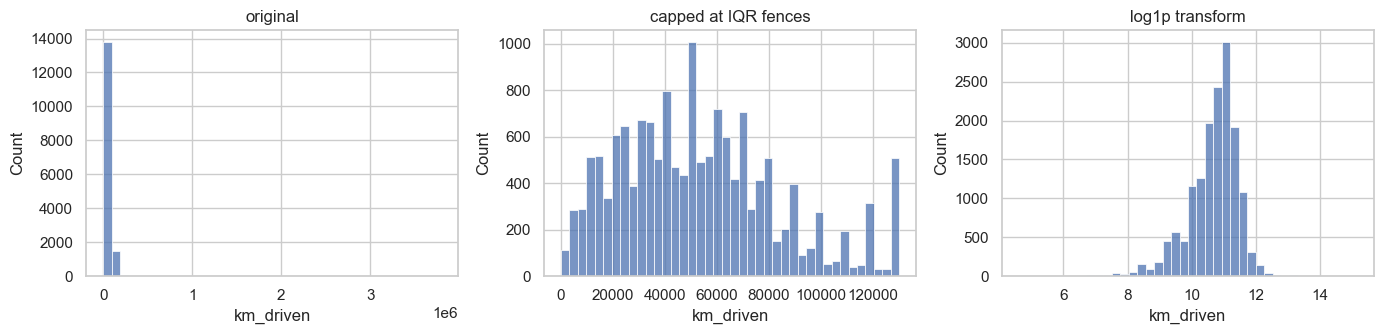

In [11]:
# Three things you can do about them
capped = df[col].clip(lower=lower, upper=upper)
logged = np.log1p(df[col])

print("original  skew:", round(df[col].skew(), 2))
print("capped    skew:", round(capped.skew(), 2))
print("log1p     skew:", round(logged.skew(), 2))

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
sns.histplot(df[col], bins=40, ax=axes[0]); axes[0].set_title("original")
sns.histplot(capped, bins=40, ax=axes[1]);  axes[1].set_title("capped at IQR fences")
sns.histplot(logged, bins=40, ax=axes[2]);  axes[2].set_title("log1p transform")
plt.tight_layout(); plt.show()

---
# 5. Data transformation & scaling

🧠 **Converting to a common currency.** One column runs 0–1, another 0–1,500,000. To a model that measures distance, the big column shouts — **not because it matters more, but because its numbers are bigger.**

In [12]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

loans = pd.read_csv(BASE + "loan_data_10k.csv").dropna().reset_index(drop=True)
cols = ["person_age", "person_income", "credit_score"]
X = loans[cols]

print("BEFORE scaling - look at the ranges:")
print(X.describe().loc[["min", "max"]].round(1))

print()
for name, scaler in [("Standard", StandardScaler()),
                     ("MinMax  ", MinMaxScaler()),
                     ("Robust  ", RobustScaler())]:
    s = scaler.fit_transform(X)
    print(f"{name}  mean {s.mean():>7.3f}   min {s.min():>7.2f}   max {s.max():>8.2f}")

BEFORE scaling - look at the ranges:
     person_age  person_income  credit_score
min        20.0         8000.0         418.0
max       144.0      2448661.0         807.0

Standard  mean   0.000   min   -4.23   max    40.70
MinMax    mean   0.213   min    0.00   max     1.00
Robust    mean   0.145   min   -3.20   max    52.14


In [13]:
# WHICH MODELS CARE? Distance- and gradient-based ones do. Trees do not.
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder

work = loans.copy()
for c in work.select_dtypes(include="object").columns:
    work[c] = LabelEncoder().fit_transform(work[c])

Xa, ya = work.drop(columns=["loan_status"]), work["loan_status"]
Xtr, Xte, ytr, yte = train_test_split(Xa, ya, test_size=.2, random_state=42, stratify=ya)

sc = StandardScaler()
Xtr_s, Xte_s = sc.fit_transform(Xtr), sc.transform(Xte)

for name, model in [("DecisionTree", DecisionTreeClassifier(max_depth=5, random_state=42)),
                    ("kNN         ", KNeighborsClassifier())]:
    raw = model.fit(Xtr, ytr).score(Xte, yte)
    scl = model.fit(Xtr_s, ytr).score(Xte_s, yte)
    print(f"{name}  unscaled {raw:.4f}   scaled {scl:.4f}   difference {scl-raw:+.4f}")

print("\nThe tree barely moves. kNN moves a lot - it measures distance.")

DecisionTree  unscaled 0.8515   scaled 0.8515   difference +0.0000
kNN           unscaled 0.7340   scaled 0.8490   difference +0.1150

The tree barely moves. kNN moves a lot - it measures distance.


---
# 6. Data encoding techniques

🧠 **Numbering roundabout exits versus numbering your friends.** Exit 3 really does come after exit 2. Friend 3 is not *more* than friend 2. **Hand a model the second kind of number and it will believe the first kind of meaning.**

In [14]:
from sklearn.preprocessing import LabelEncoder

e = LabelEncoder()
codes = e.fit_transform(loans["loan_intent"])

# LabelEncoder assigns 0,1,2... in ALPHABETICAL order.
# ALWAYS print the mapping - any app serving this model must reuse it exactly.
print(dict(zip(e.classes_, range(len(e.classes_)))))

{'DEBTCONSOLIDATION': 0, 'EDUCATION': 1, 'HOMEIMPROVEMENT': 2, 'MEDICAL': 3, 'PERSONAL': 4, 'VENTURE': 5}


In [15]:
# ONE-HOT for unordered categories: one 0/1 column each, no false ordering.
demo = pd.DataFrame({"city": ["Delhi", "Mumbai", "Chennai", "Delhi"],
                     "size": ["Small", "Large", "Medium", "Medium"]})

print("one-hot on city (unordered):")
print(pd.get_dummies(demo[["city"]], columns=["city"], dtype=int))

# An ORDERED category: set the order YOURSELF. Alphabetical would give
# Large=0, Medium=1, Small=2 - which says Small is the biggest.
order = {"Small": 0, "Medium": 1, "Large": 2}
print("\nmanual order on size:", demo["size"].map(order).tolist())
print("LabelEncoder would give:", LabelEncoder().fit_transform(demo["size"]).tolist(),
      " <- wrong ordering")

one-hot on city (unordered):
   city_Chennai  city_Delhi  city_Mumbai
0             0           1            0
1             0           0            1
2             1           0            0
3             0           1            0

manual order on size: [0, 2, 1, 1]
LabelEncoder would give: [2, 0, 1, 1]  <- wrong ordering


---
# 7. Train-test split

🧠 **Studying with the answer key.** You score 100% on every practice paper, walk into the real exam confident — and fail. **That is data leakage.**

In [16]:
from sklearn.model_selection import train_test_split

X = work.drop(columns=["loan_status"])
y = work["loan_status"]

# SPLIT FIRST. Always.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # hold back 20% the model never sees
    random_state=42,    # same split every run, so results compare
    stratify=y,         # keep the class balance in both halves
)

print("train:", X_train.shape, " test:", X_test.shape)
print("\nclass balance kept by stratify:")
print("  train:", y_train.value_counts(normalize=True).round(3).tolist())
print("  test :", y_test.value_counts(normalize=True).round(3).tolist())

train: (7997, 13)  test: (2000, 13)

class balance kept by stratify:
  train: [0.5, 0.5]
  test : [0.5, 0.5]


In [17]:
# THEN scale: fit on train, transform both.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit_transform on TRAIN
X_test_scaled  = scaler.transform(X_test)        # transform ONLY on test

print("train mean after scaling (should be ~0):", X_train_scaled.mean().round(6))

# A Pipeline makes leakage much harder - the scaler is fitted INSIDE,
# on the training portion only, including inside cross-validation.
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression

pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
pipe.fit(X_train, y_train)
print("pipeline test score:", round(pipe.score(X_test, y_test), 4))

train mean after scaling (should be ~0): 0.0
pipeline test score: 0.865


In [18]:
# HOW BADLY DOES LEAKAGE BITE? It depends entirely on WHAT leaked.
#
# 1. Scaler leakage - real, but usually small on a decent-sized dataset.

from sklearn.neighbors import KNeighborsClassifier

all_scaled = StandardScaler().fit_transform(X)                  # WRONG: all data
aXtr, aXte, aytr, ayte = train_test_split(all_scaled, y, test_size=.2,
                                          random_state=42, stratify=y)
leaky_scaler = KNeighborsClassifier().fit(aXtr, aytr).score(aXte, ayte)
correct_scaler = KNeighborsClassifier().fit(X_train_scaled, y_train).score(X_test_scaled, y_test)

print("--- scaler leakage, 10,000 rows ---")
print(f"leaky   {leaky_scaler:.4f}   correct {correct_scaler:.4f}   "
      f"difference {leaky_scaler - correct_scaler:+.4f}")
print("Tiny - within run-to-run noise. Still wrong, but it will not fool you.")

--- scaler leakage, 10,000 rows ---
leaky   0.8485   correct 0.8490   difference -0.0005
Tiny - within run-to-run noise. Still wrong, but it will not fool you.


In [19]:
# 2. TARGET-BASED leakage - catastrophic. This is the one to fear.
#
# 100 rows, 5000 columns of PURE RANDOM NOISE, and RANDOM labels.
# There is genuinely NO signal here. A model should score about 50%.

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression

rng = np.random.default_rng(0)
Xn = rng.normal(size=(100, 5000))      # pure noise
yn = rng.integers(0, 2, size=100)      # random labels

# WRONG: pick the 20 "best" features using the WHOLE dataset - target included
sel = SelectKBest(f_classif, k=20).fit(Xn, yn)
Xtr, Xte, ytr, yte = train_test_split(sel.transform(Xn), yn,
                                      test_size=.3, random_state=0, stratify=yn)
leaky = LogisticRegression(max_iter=2000).fit(Xtr, ytr).score(Xte, yte)

# RIGHT: split first, then select using the TRAINING data only
Xtr2, Xte2, ytr2, yte2 = train_test_split(Xn, yn, test_size=.3,
                                          random_state=0, stratify=yn)
sel2 = SelectKBest(f_classif, k=20).fit(Xtr2, ytr2)
correct = (LogisticRegression(max_iter=2000)
           .fit(sel2.transform(Xtr2), ytr2)
           .score(sel2.transform(Xte2), yte2))

print("--- target-based leakage, on data with NO signal at all ---")
print(f"leaky   (selected on ALL data) : {leaky:.3f}")
print(f"correct (selected on TRAIN)    : {correct:.3f}")
print(f"\nThe leaky pipeline reports {leaky:.0%} accuracy on random noise.")
print("It found the 20 columns that happened to match the labels - including")
print("the test rows. That is not a model. That is memorising the answer key.")

--- target-based leakage, on data with NO signal at all ---
leaky   (selected on ALL data) : 0.900
correct (selected on TRAIN)    : 0.500

The leaky pipeline reports 90% accuracy on random noise.
It found the 20 columns that happened to match the labels - including
the test rows. That is not a model. That is memorising the answer key.


> **The honest summary.** Scaler leakage is real but mild — you should still avoid it, and a `Pipeline` makes it automatic. **Target-based leakage is the one that ruins projects**: fitting feature selection, an imputer, or resampling on the whole dataset lets information about the test rows reach training, and the reported score becomes fiction.
>
> **The symptom is the same in both cases: a test score that looks too good.** When you see one, suspect leakage before you celebrate.

---
# ✅ Before you move on

- [ ] I pick a chart from the question, and can say what it tells me
- [ ] I check the count plot before believing a bar plot
- [ ] I can justify drop vs mean vs median vs mode, per column
- [ ] I check whether a duplicate is genuine before deleting it
- [ ] I can compute IQR fences and decide keep / cap / remove / transform
- [ ] I know which models need scaling and which do not
- [ ] I know when `LabelEncoder` would mislead a model
- [ ] I **split before I scale**, and can explain leakage with the answer-key analogy

**Exercises, MCQs and tasks:** [Session 3 guide](../sessions/session-03-visualisation-preprocessing.md)

| | |
|---|---|
| **Previous** | [Session 2 — NumPy & Pandas](../sessions/session-02-numpy-pandas.md) |
| **Next** | [Sessions index](../sessions/README.md) |
| **Stuck?** | [Troubleshooting](../troubleshooting.md) |